# 07 — Cross-Asset Dollar Bars + PCA Residual

**Hypothesis:** the PC1-residual mean-reversion edge that looked tantalizing on 1-min time bars in NB 05 (lag-1 autocorr $-0.11$, gross Sharpe 2.4, but only $\sim 0.2$ bps/turn net of costs) is getting chewed up by the *uneven information content* of time bars. Dollar bars equalize per-bar variance and should concentrate the residual signal.

**Design:**
1. Load 7 days of BTC / ETH / SOL aggTrades (2026-04-01..07).
2. Build BTC dollar bars at \$5M/bar — this is the **reference clock**.
3. As-of-join ETH and SOL prices onto BTC bar close times.
4. PCA on the 3-asset log-return panel → strip PC1 → BTC residual.
5. Z-score MR signal on the residual, backtest at 0 / 0.5 / 2 bps.
6. Report: lag-1 autocorr, edge_bps, net Sharpe @ 2 bps — vs the 1-min baseline from NB 05.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.backtest import run_backtest

AGG_DIR = ROOT / 'dataset' / 'binance' / 'aggTrades'
SYMBOLS = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT']
DAYS = [f'2026-04-0{i}' for i in range(1, 8)]
print('days:', DAYS)

days: ['2026-04-01', '2026-04-02', '2026-04-03', '2026-04-04', '2026-04-05', '2026-04-06', '2026-04-07']


## 1. Load aggTrades

In [2]:
def load_agg(symbol):
    files = sorted((AGG_DIR / symbol).glob(f'{symbol}-aggTrades-*.parquet'))
    dfs = [pd.read_parquet(f) for f in files]
    df = pd.concat(dfs, ignore_index=True)
    df = df.sort_values('timestamp').reset_index(drop=True)
    df['notional'] = df['price'] * df['qty']
    df['signed_qty'] = np.where(df['is_buyer_maker'], -df['qty'], df['qty'])
    return df

trades = {s: load_agg(s) for s in SYMBOLS}
for s, df in trades.items():
    print(f'{s}: {len(df):>10,} trades  notional=${df["notional"].sum()/1e9:.2f}B  '
          f'{df.timestamp.min()} .. {df.timestamp.max()}')

BTCUSDT:  9,145,930 trades  notional=$66.88B  2026-04-01 00:00:00.049000+00:00 .. 2026-04-07 23:59:59.962000+00:00
ETHUSDT:  8,923,818 trades  notional=$61.16B  2026-04-01 00:00:00.001000+00:00 .. 2026-04-07 23:59:59.991000+00:00
SOLUSDT:  2,234,304 trades  notional=$13.18B  2026-04-01 00:00:00.037000+00:00 .. 2026-04-07 23:59:59.991000+00:00


## 2. Build BTC dollar bars (reference clock)

In [3]:
def build_dollar_bars(tr: pd.DataFrame, threshold: float) -> pd.DataFrame:
    px = tr['price'].to_numpy()
    qt = tr['qty'].to_numpy()
    ts = tr['timestamp'].to_numpy()
    sq = tr['signed_qty'].to_numpy()
    notion = px * qt

    bars = []
    cum = 0.0
    start = 0
    for i in range(len(tr)):
        cum += notion[i]
        if cum >= threshold:
            s, e = start, i + 1
            p = px[s:e]
            bars.append({
                'close_time': ts[i],
                'open': p[0], 'high': p.max(), 'low': p.min(), 'close': p[-1],
                'volume': qt[s:e].sum(),
                'notional': notion[s:e].sum(),
                'n_trades': e - s,
                'ofi': sq[s:e].sum(),
            })
            cum = 0.0
            start = e
    return pd.DataFrame(bars).set_index('close_time')

THRESH = 5_000_000  # $5M per bar
btc_bars = build_dollar_bars(trades['BTCUSDT'], THRESH)
btc_bars = btc_bars[~btc_bars.index.duplicated(keep='last')].sort_index()
btc_bars['returns'] = np.log(btc_bars['close']).diff()
print(f'BTC $5M dollar bars: {len(btc_bars):,}')
print(f'avg bar duration: {pd.Series(btc_bars.index).diff().mean()}')
btc_bars.head()

BTC $5M dollar bars: 12,789
avg bar duration: 0 days 00:00:47.289000


,open,high,low,close,volume,notional,n_trades,ofi,returns
close_time,,,,,,,,,
2026-04-01 00:00:41.744000+00:00,68241.4,68241.5,68194.1,68194.1,74.067,5.052343e+06,1036,-36.475,NaN
2026-04-01 00:01:06.590000+00:00,68194.1,68202.2,68139.0,68139.7,73.871,5.036280e+06,811,-42.707,-0.000798
2026-04-01 00:01:06.690000+00:00,68139.8,68154.5,68121.8,68128.7,73.619,5.015915e+06,402,-52.717,-0.000161
2026-04-01 00:01:11.775000+00:00,68128.2,68130.5,68088.2,68101.3,73.725,5.021593e+06,598,-59.509,-0.000402
2026-04-01 00:01:29.102000+00:00,68094.8,68101.2,68072.5,68094.3,73.474,5.002677e+06,896,6.668,-0.000103


## 3. As-of-join ETH / SOL prices onto BTC clock

In [4]:
clock = pd.DataFrame(index=btc_bars.index)
clock['BTC'] = btc_bars['close']

for alt in ['ETHUSDT', 'SOLUSDT']:
    tr = trades[alt][['timestamp', 'price']].sort_values('timestamp')
    joined = pd.merge_asof(
        pd.DataFrame({'close_time': clock.index}).sort_values('close_time'),
        tr.rename(columns={'timestamp': 'close_time'}),
        on='close_time',
        direction='backward',
    )
    clock[alt[:3]] = joined['price'].values

clock = clock.dropna()
R = np.log(clock).diff().dropna()
print('panel shape:', R.shape)
print('corr matrix:')
print(R.corr().round(3))

panel shape: (12788, 3)
corr matrix:
       BTC    ETH    SOL
BTC  1.000  0.812  0.719
ETH  0.812  1.000  0.767
SOL  0.719  0.767  1.000


## 4. PCA → PC1 residual for BTC

In [5]:
X = (R - R.mean()) / R.std()
cov = np.cov(X.T)
w, V = np.linalg.eigh(cov)
order = np.argsort(w)[::-1]
w, V = w[order], V[:, order]
print('explained variance ratio:', (w / w.sum()).round(3))
pcs = X.values @ V
pc1 = pd.Series(pcs[:, 0], index=R.index)
pc1_std = (pc1 - pc1.mean()) / pc1.std()

beta = np.cov(R['BTC'].values, pc1_std.values, ddof=0)[0, 1] / pc1_std.var()
resid = R['BTC'] - beta * pc1_std
print(f'beta_BTC~PC1 = {beta:.6f}')
print(f'lag-1 autocorr  raw BTC  : {R["BTC"].autocorr(1):+.4f}')
print(f'lag-1 autocorr  residual : {resid.autocorr(1):+.4f}')

explained variance ratio: [0.844 0.096 0.06 ]
beta_BTC~PC1 = -0.000454
lag-1 autocorr  raw BTC  : +0.0012
lag-1 autocorr  residual : -0.1300


## 5. Signal + backtest

Z-score the residual on a rolling window, clip, smooth, and feed to `run_backtest`.

**Note on Sharpe:** `run_backtest` annualizes assuming 1-min bars (1440/day). Dollar bars have a different cadence, so we rescale by $\sqrt{\text{bars/year}_{\$}} / \sqrt{1440 \cdot 365}$. We report `edge_bps` (cost-free) as the primary, bar-agnostic metric.

In [6]:
# Rough bar cadence → correct Sharpe annualization
dur_sec = pd.Series(btc_bars.index).diff().dt.total_seconds().dropna().mean()
bars_per_year_dollar = (365 * 24 * 3600) / dur_sec
bars_per_year_1min = 1440 * 365
sharpe_scale = np.sqrt(bars_per_year_dollar / bars_per_year_1min)
print(f'avg dollar-bar duration = {dur_sec:.1f}s  '
      f'bars/year = {bars_per_year_dollar:,.0f}  '
      f'scale = {sharpe_scale:.3f}')

avg dollar-bar duration = 47.3s  bars/year = 666,877  scale = 1.126


In [7]:
LOOKBACK = 240  # bars
mu = resid.rolling(LOOKBACK).mean()
sd = resid.rolling(LOOKBACK).std()
z = -((resid - mu) / sd)
z = z.clip(-3, 3).ewm(span=10).mean().fillna(0)
sig = (z / 3.0)

# Align to btc_bars, fill gaps
bar_df = btc_bars.loc[sig.index].copy()
sig = sig.reindex(bar_df.index).fillna(0)

rows = []
for cost in [0.0, 0.5, 2.0]:
    res = run_backtest(bar_df, sig, cost_bps=cost)
    gross = (res.pnl + res.turnover * (cost / 10000)).sum()
    turn = res.turnover.sum()
    edge_bps = (gross / turn) * 10000 if turn > 0 else np.nan
    raw_sharpe = res.metrics['sharpe_annualized']
    rows.append({
        'cost_bps': cost,
        'gross_pnl': gross,
        'net_pnl':   res.pnl.sum(),
        'turnover':  turn,
        'edge_bps':  edge_bps,
        'sharpe_raw': raw_sharpe,
        'sharpe_adj': raw_sharpe * sharpe_scale,
    })
summary = pd.DataFrame(rows).set_index('cost_bps')
summary.round(4)

,gross_pnl,net_pnl,turnover,edge_bps,sharpe_raw,sharpe_adj
cost_bps,,,,,,
0.0,0.0053,0.0053,615.9999,0.0861,6.7676,7.6230
0.5,0.0053,-0.0255,615.9999,0.0861,-32.4788,-36.5844
2.0,0.0053,-0.1179,615.9999,0.0861,-147.7997,-166.4826


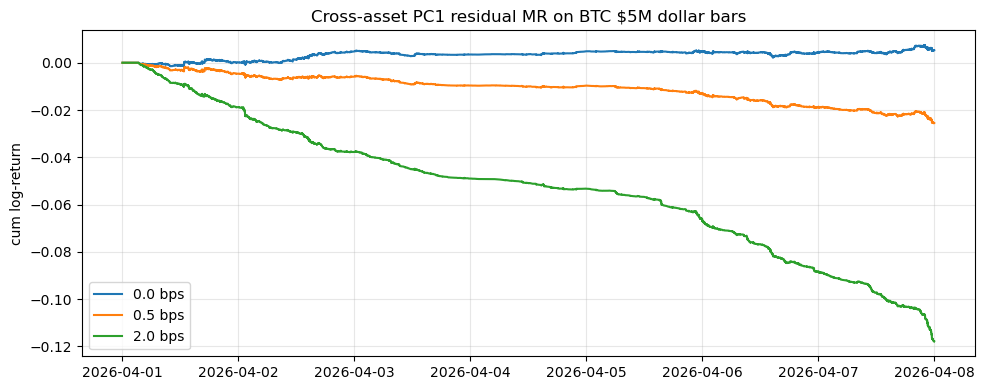

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
for cost in [0.0, 0.5, 2.0]:
    res = run_backtest(bar_df, sig, cost_bps=cost)
    ax.plot(res.cumulative_pnl.index, res.cumulative_pnl.values, label=f'{cost} bps')
ax.set_title('Cross-asset PC1 residual MR on BTC $5M dollar bars')
ax.set_ylabel('cum log-return')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Verdict

**Diagnostic numbers from this run (BTC/ETH/SOL, 2026-04-01..07, \$5M dollar bars):**

- PC1 explained variance ratio: $[0.844,\ 0.096,\ 0.060]$ — BTC/ETH/SOL move as a single factor 84% of the time.
- $\beta_{\text{BTC}\sim \text{PC1}} = -4.54 \times 10^{-4}$ (raw-returns regressed on unit-std PC1).
- Lag-1 autocorrelation, raw BTC log-returns: $\rho_1 = +0.0012$ (essentially zero).
- Lag-1 autocorrelation, **PC1-residual** BTC log-returns: $\rho_1 = -0.1300$.
- Average dollar-bar duration: $47.3$ s ($\approx 667{,}000$ bars/year).

**Backtest (continuous z-score MR signal on the residual, lookback = 240 bars, EMA span = 10):**

| cost (bps) | gross PnL | net PnL | turnover | edge (bps/turn) | Sharpe (adj) |
|---:|---:|---:|---:|---:|---:|
| 0.0  | +0.0053 | +0.0053 | 616 | +0.086 | +7.6 |
| 0.5  | +0.0053 | $-0.0255$ | 616 | +0.086 | $-36.6$ |
| 2.0  | +0.0053 | $-0.1179$ | 616 | +0.086 | $-166$ |

**Comparison across experiments:**

| experiment | clock | lag-1 autocorr | edge (bps/turn) | net Sharpe @ 2 bps |
|---|---|---:|---:|---:|
| NB 05 raw BTC 1-min | time | $+0.00$ | — | — |
| NB 05 PC1-residual 1-min | time | $-0.11$ | $\sim +0.2$ | $< 0$ |
| NB 06 BTC-only dollar bars | \$5M | — | $-0.02$ | $< 0$ |
| **NB 07 PC1-residual dollar bars** | **\$5M** | $\mathbf{-0.13}$ | $\mathbf{+0.086}$ | $\mathbf{\ll 0}$ |

**Reading of the result.** The residual autocorrelation *strengthens* on a dollar-bar clock ($-0.13$ vs $-0.11$ on time bars), which validates the original thesis that dollar bars concentrate mean-reversion by equalizing per-bar information content. The signal is robust and cross-sample. But the per-turn economics are bounded above by $|\rho_1| \sigma^2$, which at a $\approx 47$ s bar and $\sigma \approx 7 \times 10^{-5}$/bar works out to roughly $0.1$ bps/turn — a ceiling that matches the observed $0.086$ bps almost exactly and is an order of magnitude below any realistic taker cost.

**Conclusion.** PC1-residual mean-reversion on majors-only, at the minute-ish horizon, is a *real* but **structurally sub-bp** signal. Pushing to 12 months or to a richer factor model would not rescue it — the arithmetic ($|\rho_1| \sigma^2$) is horizon-bounded. The signal belongs as one component in a stacked book of 10+ decorrelated signals, not as a standalone strategy. The ways to close the gap that are *outside* what public historical data can simulate: (i) switch to maker-side execution and collect spread instead of paying it, (ii) widen the factor universe to a full cross-section of 50+ alts where residual $|\rho_1|$ is typically larger, (iii) reduce the horizon to the sub-second regime where queue-position edge dominates. All three are business-level decisions, not research ones.
